# CSV_file_Linear_Regression

### 입력 1개, 출력 1개인 Linear Regression을 구현하라
### (Colab을 사용하는 경우 "files/LinearRegression.csv"를 "내 드라이브/files/"에 복사)

>### Load modules

In [1]:
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

if tf.__version__ >= '2.17.0':
    from tf_keras import optimizers
else:
    from tensorflow.keras import optimizers

print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("pandas Version :{}".format(pd.__version__))

NumPy Version :1.26.4
TensorFlow Version :2.18.0
pandas Version :2.2.2


> ### Input and Label

In [2]:
colab=True
try:
  from google.colab import drive
except:
  colab =False
if colab :
    drive.mount('/content/drive')
    print('g-drive mounted.')
else : print('local drive.')

Mounted at /content/drive
g-drive mounted.


In [3]:
# file path: 다른 경로에 실습파일을 복사했다면, 아래 경로를 수정하세요

if colab :
  files_path = '/content/drive/MyDrive/[SOL]LAB_01_CSV_file_Linear_Regression/files/LinearRegression.csv'
else :
  files_path = '../files/LinearRegression.csv'

In [4]:
# LinearRegression.csv 파일 읽기
# pd.set_option('display.max_rows', None) ## 모든 행을 출력한다.
df = pd.read_csv(files_path)
df.head()

,X,Y
0,1,3.888889
1,2,4.555556
2,3,5.222222
3,4,5.888889
4,5,6.555556


In [5]:
df[['X','Y']]

,X,Y
0,1,3.888889
1,2,4.555556
2,3,5.222222
3,4,5.888889
4,5,6.555556
...,...,...
295,296,200.555556
296,297,201.222222
297,298,201.888889
298,299,1.888889


In [6]:
x_input = tf.constant(df['X'], dtype=tf.float32)
labels = tf.constant(df['Y'], dtype=tf.float32)

print(x_input.shape, labels.shape)

(300,) (300,)


In [7]:
x_input = tf.reshape(x_input, (-1,1))
labels = tf.reshape(labels, (-1,1))

print(x_input.shape, labels.shape)

(300, 1) (300, 1)


In [8]:
# 1. W, B 정의
n_in, n_out = 1, 1
W = tf.Variable(tf.random.normal((n_in, n_out)), dtype=tf.float32)
B = tf.Variable(tf.random.normal((n_out,)), dtype=tf.float32)

In [9]:
# 2. Min Max Scaler
x_input_org = x_input
x_min, x_max = np.min(x_input, axis=0), np.max(x_input, axis=0)
x_input = (x_input-x_min)/(x_max-x_min)

In [10]:
# 3. Hypothesis() 정의
def Hypothesis(x):
  return tf.matmul(x, W) + B

In [11]:
# 4. Cost() 정의
def Cost():
  return tf.reduce_mean(tf.square(Hypothesis(x_input)-labels))

In [12]:
# 5. Training

In [18]:
%%time
# Parameter Set
epochs = 2000
learning_rate = 0.05
optimizer = optimizers.SGD(learning_rate=learning_rate)

training_idx = np.arange(0, epochs+1, 1)
cost_graph = np.zeros(epochs+1)

for cnt in range(0, epochs+1):
  cost_graph[cnt] = Cost()
  if cnt % (epochs/20) == 0:
      print("[{:>6}] cost={:>6.4}, W = {}, B = {}".format(cnt, cost_graph[cnt], W.numpy(), B.numpy()))

  optimizer.minimize(Cost,[W, B])

[     0] cost=1.347e+04, W = [[0.5873128]], B = [1.1577423]
[   100] cost= 742.4, W = [[116.19921]], B = [46.783424]
[   200] cost= 388.5, W = [[152.68222]], B = [27.249392]
[   300] cost= 294.7, W = [[171.46423]], B = [17.192894]
[   400] cost= 269.9, W = [[181.13347]], B = [12.0156765]
[   500] cost= 263.3, W = [[186.11137]], B = [9.350353]
[   600] cost= 261.6, W = [[188.67412]], B = [7.9781766]
[   700] cost= 261.1, W = [[189.99341]], B = [7.271779]
[   800] cost= 261.0, W = [[190.67259]], B = [6.908133]
[   900] cost= 260.9, W = [[191.02223]], B = [6.720916]
[  1000] cost= 260.9, W = [[191.2023]], B = [6.624502]
[  1100] cost= 260.9, W = [[191.29497]], B = [6.574891]
[  1200] cost= 260.9, W = [[191.34267]], B = [6.549347]
[  1300] cost= 260.9, W = [[191.36722]], B = [6.5362043]
[  1400] cost= 260.9, W = [[191.3798]], B = [6.529458]
[  1500] cost= 260.9, W = [[191.38625]], B = [6.5260015]
[  1600] cost= 260.9, W = [[191.38968]], B = [6.5241957]
[  1700] cost= 260.9, W = [[191.39127

In [19]:
# 6. Hypothesis test (x_input 사용)
H_x = Hypothesis(x_input)
for x,h,l in zip(x_input_org, H_x, labels):
  print("x:{}, h:{}, l:{}".format(x,h,l))

x:[1.], h:[6.522701], l:[3.8888888]
x:[2.], h:[7.162809], l:[4.5555553]
x:[3.], h:[7.8029175], l:[5.2222223]
x:[4.], h:[8.443026], l:[5.888889]
x:[5.], h:[9.083134], l:[6.5555553]
x:[6.], h:[9.723242], l:[7.2222223]
x:[7.], h:[10.36335], l:[7.888889]
x:[8.], h:[11.003459], l:[8.555555]
x:[9.], h:[11.643567], l:[9.222222]
x:[10.], h:[12.283675], l:[9.888889]
x:[11.], h:[12.923783], l:[10.555555]
x:[12.], h:[13.563892], l:[11.222222]
x:[13.], h:[14.204], l:[11.888889]
x:[14.], h:[14.844109], l:[12.555555]
x:[15.], h:[15.484217], l:[13.222222]
x:[16.], h:[16.124325], l:[13.888889]
x:[17.], h:[16.764433], l:[14.555555]
x:[18.], h:[17.404543], l:[15.222222]
x:[19.], h:[18.04465], l:[15.888889]
x:[20.], h:[18.68476], l:[16.555555]
x:[21.], h:[19.324865], l:[17.222221]
x:[22.], h:[19.964975], l:[17.88889]
x:[23.], h:[20.605083], l:[18.555555]
x:[24.], h:[21.245192], l:[19.222221]
x:[25.], h:[21.8853], l:[19.88889]
x:[26.], h:[22.525408], l:[20.555555]
x:[27.], h:[23.165518], l:[21.222221]
x:[

In [20]:
# 7. Predict (X가 115.5일 경우 Y 예측)
def predict(x):
  return Hypothesis((x-x_min)/(x_max-x_min))

X = tf.constant([[115.5]], dtype= tf.float32)
print("X: {} -> Y: {:>7.4}".format(X[0,0], predict(X)[0,0]))

X: 115.5 -> Y:   79.82


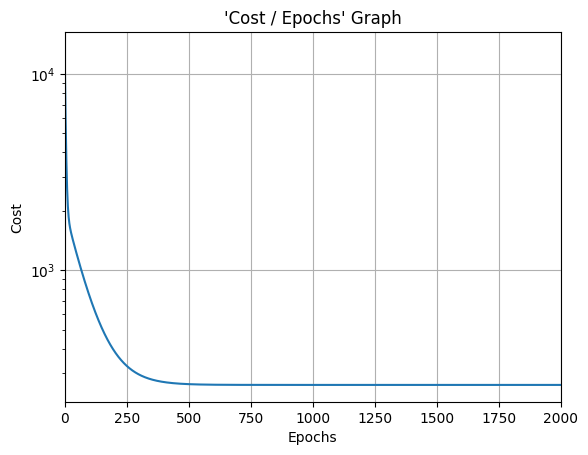

In [21]:
# 8. Training 회수 별 Cost 값을 그래프로 출력
plt.title("'Cost / Epochs' Graph")
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.plot(training_idx, cost_graph)
plt.xlim(0, epochs)
plt.grid(True)
plt.semilogy()
plt.show()

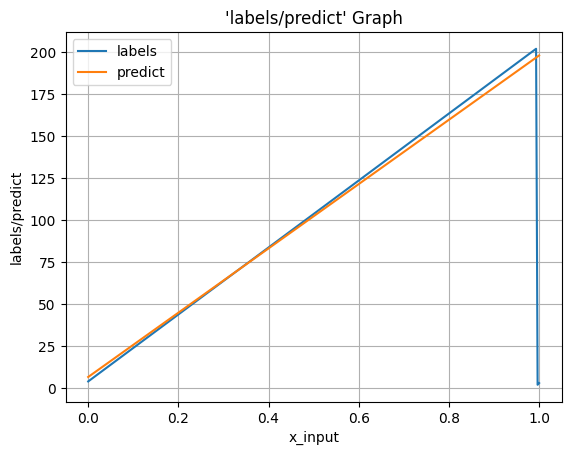

In [22]:
# 9. labels(정답)과 predict(예측값)를 비교할 수 있는 그래프 출력

H_x = Hypothesis(x_input)

plt.title("'labels/predict' Graph")
plt.xlabel("x_input")
plt.ylabel("labels/predict")
plt.plot(x_input.numpy().reshape((-1,)), labels.numpy().reshape((-1,)), label='labels')
plt.plot(x_input.numpy().reshape((-1,)), H_x.numpy().reshape((-1,)), label='predict')
plt.grid(True)
plt.legend(loc='best')
plt.show()